In [3]:
from itertools import combinations
from scipy.stats import multivariate_normal
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import numpy as np
from sympy import var
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
from numba import jit
import scipy

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
plt.rc('font', size=18) 

from scipy.interpolate import interp1d
from scipy.integrate import odeint

In [85]:
def normal_corner(covm,mean,varlabels,fixedvarindex=None,fixedvarvalue=None,
           covm2=None,mean2=None,scale_factor=3,diagnostic=False,
                  color='red',color2='blue', figsize=(12,6), **fig_kw):
    
    """Taken for normal contour - https://github.com/bvgoncharov/normal_corner/blob/master/normal_corner/normal_corner.py
    and edited the initial subplot creation"""
    
    """ 
    indexing now works like | plot_id |- for 3x3 matrix - 1 D variance not included - we index from the origin (sorry)
    
    2   | 5 |
    1   | 3 | 4 |
    0   | 0 | 1 | 2 |
       
          3   2   1
    
    So we create
    """

    # Plotting 2D contour distributions
    N = len(mean)
    
    fig = plt.figure(figsize=figsize)    
    
    # Define gridspec with N-1 rows and N-1 columns
    N_grid = N-1
    gs = GridSpec(N_grid, N_grid)

    # get corner structure
    axs = []
    for i in range(N_grid)[::-1]:
        for j in range(i+1):
            ax = fig.add_subplot(gs[i, j])
            axs.append(ax)
    
    axs1 = []
    #for pairs    
    for pair in combinations(range(N),2):
        #need to map pair to grid layour like the diagram
        y_ind = pair[0]*N_grid - pair[0]*(pair[0]-1)/2
        plot_id = int(y_ind + (N_grid-pair[1])) # index row and then column - see diagram above
        print(plot_id)
        print(pair)
        ax = axs[plot_id]
        lim = axis_limits(covm,mean,pair,scale_factor)

        ax, cp = contour_plot_pair(ax,covm,mean,pair,color,lim,varlabels)
        axs1.append(ax)

    plt.subplots_adjust(wspace=0, hspace=0)#

    return fig,axs1

### Helper functions ###

def contour_plot_pair(ax,covm,mean,pair,color,lim,varlabels):
    
    twocov = covm[np.ix_(pair,pair)]
    twomu = mean[np.ix_(pair)]
    
    rv = multivariate_normal(twomu, twocov)
    
    rv_sigma=[]
    #rv_sigma.append(rv.pdf( np.dstack((twomu[0], twomu[1]+3*twocov[1,1]**0.5)) ))
    rv_sigma.append(rv.pdf( np.dstack((twomu[0], twomu[1]+2*twocov[1,1]**0.5)) ))
    rv_sigma.append(rv.pdf( np.dstack((twomu[0], twomu[1]+1*twocov[1,1]**0.5)) ))
    print(rv_sigma)
    xvals, yvals = np.mgrid[lim['minvaly']:lim['maxvaly']:.01*(lim['maxvaly']-lim['minvaly']), lim['minvalx']:lim['maxvalx']:.01*(lim['maxvalx']-lim['minvalx'])]
    pos = np.dstack((xvals, yvals))
    
    cp = ax.contour(yvals, xvals, rv.pdf(pos), rv_sigma, colors=color, linestyles=['dotted','solid'],linewidths=1)
    ax = configure_axis(ax,len(mean)-1,pair,varlabels)
    
    return ax, cp

def axis_limits(covm,mean,pair,scale_factor):
    ''' Choose axis limits on the basis of two covariance matrices and a scale factor '''
    
    lim = dict()
    
    lim['minvaly'] = mean[pair[0]]-scale_factor*covm[pair[0]][pair[0]]**0.5
    lim['maxvaly'] = mean[pair[0]]+scale_factor*covm[pair[0]][pair[0]]**0.5
    lim['minvalx'] = mean[pair[1]]-scale_factor*covm[pair[1]][pair[1]]**0.5
    lim['maxvalx'] = mean[pair[1]]+scale_factor*covm[pair[1]][pair[1]]**0.5

    return lim

def configure_axis(ax,N_grid,pair,varlabels):
    '''
    Remove axis for subplots that are not adjacent to bottom and left corner plot edges
    Set axis labels for remaining axis
    '''
    
    if pair[0]==0:
        ax.set_xlabel(varlabels[pair[1]])
    else:
        ax.xaxis.set_major_locator(plt.NullLocator())
        
    
    if pair[1]==N_grid:
        ax.set_ylabel(varlabels[pair[0]])
    else:
        ax.yaxis.set_major_locator(plt.NullLocator())
    

    return ax


1
(0, 1)
[0.02153927930184863, 0.09653235263005391]
0
(0, 2)
[0.012435708703072845, 0.05573297977646952]
2
(1, 2)
[6.16500800322613e-05, 0.024871417406145693]


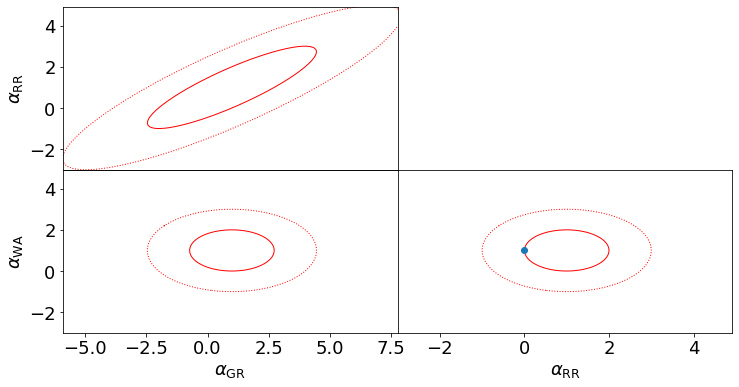

In [86]:
#from normal_corner import normal_corner

### EXAMPLE 1: plotting one covariance matrix ###

# Covariance matrix, as a numpy array
covm = np.array([[1, 0, 0], [0, 1.0, 1.5], [0,1.5,3.0]])


# Mean matrix, as a numpy array
mean = np.array([1, 1, 1])


# Variable labels for plotting, as a list of strings
# in LaTeX format, between $$ symbols
varlabels = ['$\\alpha_{\\rm WA}$','$\\alpha_{\\rm RR}$','$\\alpha_{\\rm GR}$']

# Make a corner plot
fig1,axs = normal_corner(covm,mean,varlabels,scale_factor=4)
axs[0].plot(1-1,1,'o')
plt.show()